# Recommendation systems

In [1]:
import pandas as pd
import numpy as np

## Load the data

In [2]:
df = pd.read_csv('data/data_train.csv')
df.head()

,uid,mid,rating
0,462,214,4.0
1,638,2275,3.0
2,310,2452,3.5
3,319,1654,4.0
4,119,270,3.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90004 entries, 0 to 90003
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     90004 non-null  int64  
 1   mid     90004 non-null  int64  
 2   rating  90004 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.1 MB


In [4]:
df['uid'].sort_values().unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [5]:
df['mid'].sort_values().unique()

array([   0,    1,    2, ..., 9063, 9064, 9065], shape=(8716,))

In [6]:
df_train = df
df_test = pd.read_csv('data/data_test.csv')
train, test = df_train.to_numpy(), df_test.to_numpy()

train.shape, test.shape

((90004, 3), (10000, 3))

The ``data_train.csv`` contains 90% of all the available data, while ``data_test.csv`` containts the remaining 10%.

We will train our recommendation systems using the train data.

In [7]:
from sklearn.metrics import root_mean_squared_error

def calculate_rmse(y_pred, y_true: np.array):
    return root_mean_squared_error(y_true=y_true, y_pred=y_pred)

## First approach: Recommend the averages

The first two algorithms we will try are the **User Average (UA)** and **Item Average (IE)**. They are really simple algorithms and they will serve as our baseline recommendation systems.

**User Average** simply for each pair (u,m) predicts the average rating of the user u.

**Item Average** simply for each pair (u,m) predicts the average rating of the movie m.

In other words, they say: 
- The user u rates the movie m with a rating equal to his mean rating.
- The movie m has a rate equal to the mean rating it has receiced.

In [8]:
# returns the average rating of each user
def user_average(data: pd.DataFrame):
    return data.groupby('uid')['rating'].mean()

# returns the average rating of each movie
def item_average(data: pd.DataFrame):
    return data.groupby('mid')['rating'].mean()

We may come across this problem: a user that exist in the training data may not exist in the test data. Likewise, a movie that exists in the training data, may not exist in the test data. To counter this, we will just predict the respected averages of the training data.

In [9]:
# spits out predictions on the test data based on the User Average algorithm
def user_average_recommendation_system(train_data, test_data):
    ua_recommendations = user_average(train_data)
    global_mean = train_data['rating'].mean() # for missing users

    test_data['preds'] = test_data['uid'].map(ua_recommendations)
    test_data['preds'] = test_data['preds'].fillna(global_mean)

    y_pred = test_data['preds'].to_numpy()
    y_true = test_data['rating'].to_numpy()
    test_data = test_data.drop(columns=['preds'])

    return y_true, y_pred

# spits out predictions on the test data based on the Item Average algorithm
def item_average_recommendation_system(train_data, test_data):
    ia_recommendations = item_average(train_data)
    global_mean = train_data['rating'].mean() # for missing items

    test_data['preds'] = test_data['mid'].map(ia_recommendations)
    test_data['preds'] = test_data['preds'].fillna(global_mean)

    y_pred = test_data['preds'].to_numpy()
    y_true = test_data['rating'].to_numpy()
    test_data = test_data.drop(columns=['preds'])

    return y_true, y_pred

Now that we are ready, we run the algorithms, calculate the RMSE and compare them.

In [11]:
y_true_ua, y_pred_ua = user_average_recommendation_system(df_train, df_test)
y_true_ia, y_pred_ia = item_average_recommendation_system(df_train, df_test)

ua_RMSE = calculate_rmse(y_true=y_true_ua, y_pred=y_pred_ua)
ia_RMSE = calculate_rmse(y_true=y_true_ia, y_pred=y_pred_ia)

print(f'User average RMSE: {ua_RMSE}')
print(f'Item average RMSE: {ia_RMSE}')

User average RMSE: 0.9612850028952498
Item average RMSE: 0.9860185686573368


As we see, the User Average algorithm performs slightly better than the Item Average algorithm. This could be the case because it predicts based on the user's average ratings, while the Item Average does not consider the user's at all, but only the overall rating of the movies.

## Second approach: Singular Value Decomposition

We will now move into Model-Based Collaborating Filtering. We will use **Singular Value Decomposition** in order to capture latent features about the ratings. Our recommendation system will work like this:

>**Rating**: for each (user, movie) pair, use the value of $R_k[u,m]$ of the rank-$k$ approximation matrix $R_k$ of the matrix $R$ for different values of $k$.

We will calculate the SVD for K=20. Then, for each k in [1 .. 20], for each pair (u,m) in the test data, we will calculate the value $R_k[u,m]$. **WE WILL NOT CREATE THE MATRIX $R_K$**, which is dense. Instead, we will create a sparse matrix.

The value $R_k[u,m]$ can be calculated as: $$R_k[u,m]=U_k[u,:]\Sigma_kV_k^T[:,m]$$

where $U_k[u,:]$ is the row $u$ of the matrix $U_k$ with the k first left singular vectors, $\Sigma_k$ is the diagonal matrix with the k largest singular values and $V_k^T[:,m]$ is the row $m$ of the transpose matrix $V_k$ with the k first right singular vectors.

### Step 1: Load the dataset into a sparse user-movie matrix


In [12]:
from scipy.sparse import csr_matrix

In [13]:
R = csr_matrix((train[:, 2], (train[:,0].astype(int), train[:,1].astype(int))))
R

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 90004 stored elements and shape (671, 9066)>

We import a version of **SVD**, that applies Singular Value Desomposition to sparse matrices. 

### Step 2: Run SVD and obtain predictions

In [14]:
from scipy.sparse.linalg import svds

We set $K=20$ and obtain the matrices $U_k, \Sigma_k, V_k^T$ .

In [15]:
K=20

u, s, vh = svds(R, k=20)

u.shape, s.shape, vh.shape

((671, 20), (20,), (20, 9066))

Since this implementation gives us back the singular values $\sigma$ in ascending order, we need to reverse them. Also, turn the $\Sigma_k$ into a diagonal matrix.

In [16]:
s = s[::-1]
u = u[:, ::-1]
vh = vh[::-1, :]

vs = vh.T.dot(np.diag(s))
vs.shape, u.shape

((9066, 20), (671, 20))

In [17]:
def predict_svd_rating(k: int, data: np.array):
    u_test = u[data[:, 0].astype(int), :k]
    v_test = vs[data[:,1].astype(int), :k] 

    return np.sum(u_test*v_test, axis=1)

In [18]:
rmse_svd = {}
for k in range(1, K+1):
    score = calculate_rmse(y_pred=predict_svd_rating(k, test), y_true=test[:,2])
    rmse_svd[k] = score
    print(f'Score for k={k}: {score}')

Score for k=1: 3.1705104872547225
Score for k=2: 3.0739018696795437
Score for k=3: 3.012785237900896
Score for k=4: 2.9836752140569103
Score for k=5: 2.9654189040799674
Score for k=6: 2.9465963167675073
Score for k=7: 2.9261732374302496
Score for k=8: 2.9281677632452943
Score for k=9: 2.92381081380281
Score for k=10: 2.927465820838587
Score for k=11: 2.9221673984986993
Score for k=12: 2.9315748120981793
Score for k=13: 2.925905491996946
Score for k=14: 2.922052827482699
Score for k=15: 2.9212186552895205
Score for k=16: 2.9296377889343175
Score for k=17: 2.935577782953288
Score for k=18: 2.940834862674277
Score for k=19: 2.948276296672239
Score for k=20: 2.951852414460193


The **SVD** performs worse that our baseline algorithms!! Our mistake or some greater truth?? Who knows!

The best run is definetly the run with $K=15$, which produces a RMSE of aprox. 2.921.

In [19]:
svd_RMSE = rmse_svd[15]

## Third approach: User-Based Collaborative Filtering

### Step 1: Create utility functions that will be used for the UCF algorithm

In [20]:
def user_mean(R: csr_matrix, u: int):
    return R[R[u, :].nonzero()].mean()


print(f"User 0 mean rating: {user_mean(R, 0)}\n")

def item_users(R: csr_matrix, m: int):
    return R[:,m].nonzero()[0]

users_movie_m = item_users(R, 0)
print(f"Users that have rated movie 0: {users_movie_m}\n\tcount: {users_movie_m.shape[0]}\n")

User 0 mean rating: 2.5588235294117645

Users that have rated movie 0: [  0   6  30  31  35  38  72  87  95 109 110 149 160 185 241 253 287 309
 310 324 337 340 393 451 456 467 484 486 495 510 515 524 589 595 600 606
 618 638 640]
	count: 39



In [21]:
from sklearn.metrics.pairwise import cosine_similarity

def similar_users(R: csr_matrix, u: int, m_users: np.array, k: int):
    sims = cosine_similarity(R[u], R[m_users]).flatten()

    topk_idx = np.argsort(sims)[::-1]
    return m_users[topk_idx[:k]], sims[topk_idx[:k]]

top_10, sims = similar_users(R, 0, train[:100,0], 10)
print(f"10 most similar usersto user 0: {top_10}")
print(f"Their similarity\n: {sims}")

10 most similar usersto user 0: [  0. 118. 231. 584. 467. 467. 467. 467. 524. 508.]
Their similarity
: [1.         0.10326345 0.08585197 0.08447731 0.08268925 0.08268925
 0.08268925 0.08268925 0.08002754 0.07795851]


The UCF score of a (u,m) pair is calculated as:

$$
p(u,m)=\frac{\sum_{u'\in N_k(u,m)}sim(u,u')R[u',m]}{\sum_{u' \in N_k(u,m)}sim(u,u')}
$$

where $N_k$ the $k$ most similar users of $u$.

We implement it in the ``compute_score(k_ratings, k_similarities)`` function.

In [22]:
def compute_score(k_ratings: np.array, k_similarities: np.array):
    denominator = np.sum(k_similarities)

    # to avoid division by zero
    if denominator == 0:
        return 0
    return k_ratings.dot(k_similarities) / denominator

We define the function ``ucf_predict(u,m,k)``, which for a given $(u,m)$ pair, predicts the rating of the user $u$ for the movie $m$, where $k$ the number of similar users we will take into account for the prediction

### Step 2: Make actual predictions

In [23]:
def ucf_predict(u: int, m: int, k: int):
    users_predicted_movie = item_users(R=R, m=m) # users that have rated the movie m
    
    # case if no users have rated movie m => assign average rating of user u
    if len(users_predicted_movie) == 0:
        return user_mean(R=R, u=u)
    
    best_k_users, sims = similar_users(R=R, u=u, m_users=users_predicted_movie, k=k)
    
    return compute_score(k_ratings=R[best_k_users, m].toarray().flatten(), k_similarities=sims)

print(f"Predicted rating of user 0 for movie 0, looking at the 10 most similar users: {ucf_predict(0,0,10)}")
print(f"Actual rating: {R[0,0]}")

Predicted rating of user 0 for movie 0, looking at the 10 most similar users: 3.062403018977041
Actual rating: 2.5


Now, we define the function ``predict_ucf_ratings(data, k)`` to predict the ratings for our test data.

In [24]:
def predict_ucf_ratings(data: np.ndarray, k: int):
    N = data.shape[0]
    users = data[:,0].astype(int)
    movies = data[:,1].astype(int)
    preds = np.zeros(N)
    for i in range(N):
        preds[i] = ucf_predict(users[i], movies[i], k)

    return preds

print(f"First 10 predictions, looking at 10 similar users: {predict_ucf_ratings(test, 10)[:10]}")
print(f"Actual ratings of the 10 first records: {test[:10,2]}")

First 10 predictions, looking at 10 similar users: [2.83712525 3.43099715 1.62050266 3.9116858  3.53225665 3.8334446
 2.65236464 2.93973213 2.86172448 3.95374836]
Actual ratings of the 10 first records: [4.5 3.  3.  3.  4.  2.  2.  3.  4.  4.5]


In [25]:
%%time
results_test_10 = predict_ucf_ratings(test, 10)

print(f"First 10 predictions, looking at 10 similar users: {results_test_10[:10]}")
print(f"Actual ratings of the 10 first records: {test[:10,2]}\n")

print(f"RMSE: {calculate_rmse(y_pred=results_test_10, y_true=test[:,2])}")

First 10 predictions, looking at 10 similar users: [2.83712525 3.43099715 1.62050266 3.9116858  3.53225665 3.8334446
 2.65236464 2.93973213 2.86172448 3.95374836]
Actual ratings of the 10 first records: [4.5 3.  3.  3.  4.  2.  2.  3.  4.  4.5]

RMSE: 1.1545617925568454
CPU times: user 9.03 s, sys: 0 ns, total: 9.03 s
Wall time: 9.03 s


### Step 3: Finding the optimal `k`

Now we run the algorithm for different $k$ values and get back a matrix, each row contains the predictions for our data, given the value $k$.

In [26]:
K = np.array([1,2,3,5,10,20,30,40,50,60,70,80,90,100])

def predict_ucf_rating_tune(test_data: np.ndarray, k: np.array):
    N = test_data.shape[0]
    users = test[:,0].astype(int)
    movies = test[:,1].astype(int)
    preds = np.zeros((len(k),N))
    
    for i, k in enumerate(k):
        preds[i,:] = np.array([ucf_predict(u,m,k) for u,m in zip(users, movies)])

    return preds

In [27]:
%%time

results_test_tune = predict_ucf_rating_tune(test, K)

for i in range(14):
    print(f"RMSE for k={K[i]}: {calculate_rmse(y_pred=results_test_tune[i,:], y_true=test[:,2])}")

RMSE for k=1: 1.372299275922044
RMSE for k=2: 1.244739258381869
RMSE for k=3: 1.2054113780296905
RMSE for k=5: 1.1739914753461016
RMSE for k=10: 1.1545617925568454
RMSE for k=20: 1.1496411856483066
RMSE for k=30: 1.1486588479056647
RMSE for k=40: 1.1491592451636194
RMSE for k=50: 1.1493195775774894
RMSE for k=60: 1.1496075786640982
RMSE for k=70: 1.1495333106212333
RMSE for k=80: 1.1496563007644052
RMSE for k=90: 1.149904865774143
RMSE for k=100: 1.1500794150887899
CPU times: user 2min 8s, sys: 23.2 ms, total: 2min 8s
Wall time: 2min 8s


Given the results, we plot the $RMSE$ of each value of $k$.

RMSE for k=1: 1.372299275922044
RMSE for k=2: 1.244739258381869
RMSE for k=3: 1.2054113780296905
RMSE for k=5: 1.1739914753461016
RMSE for k=10: 1.1545617925568454
RMSE for k=20: 1.1496411856483066
RMSE for k=30: 1.1486588479056647
RMSE for k=40: 1.1491592451636194
RMSE for k=50: 1.1493195775774894
RMSE for k=60: 1.1496075786640982
RMSE for k=70: 1.1495333106212333
RMSE for k=80: 1.1496563007644052
RMSE for k=90: 1.149904865774143
RMSE for k=100: 1.1500794150887899
Minimum RMSE achieved for K=30: 1.1486588479056647


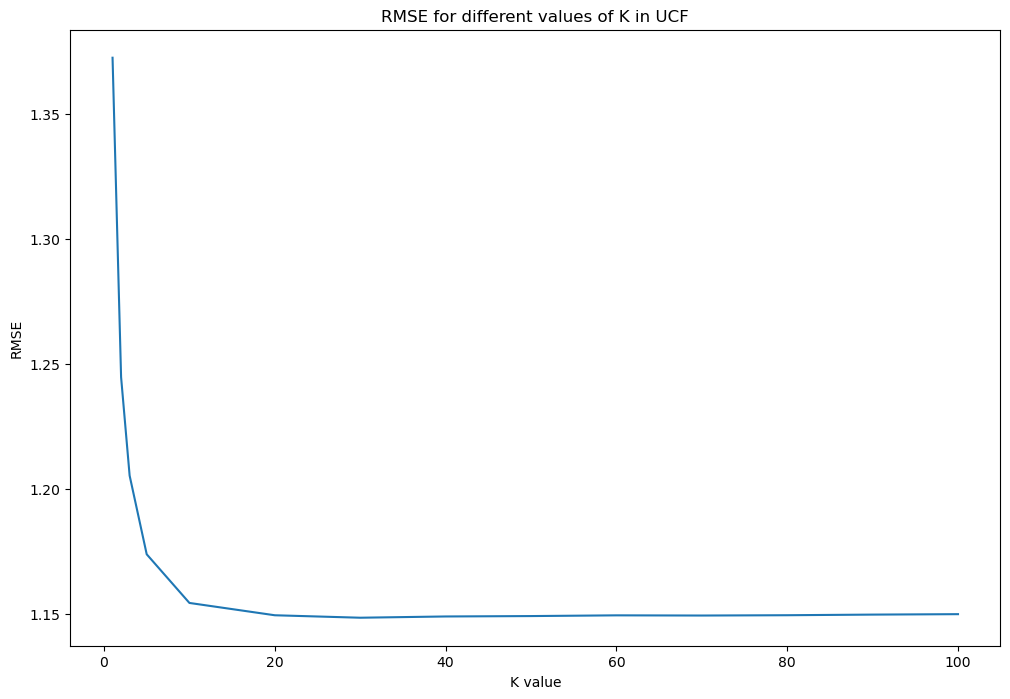

In [28]:
import matplotlib.pyplot as plt

x = []
y = []
min_rmse = 100000
min_k = -1
for row in range(14):
    x.append(K[row])
    y.append(calculate_rmse(y_pred=results_test_tune[row], y_true=test[:,2]))
    print(f'RMSE for k={x[-1]}: {y[-1]}')

    if min_rmse > y[-1]:
        min_rmse = y[-1]
        min_k = x[-1]

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x,y)
ax.set(
    title="RMSE for different values of K in UCF",
    xlabel="K value",
    ylabel="RMSE",
)

print(f'Minimum RMSE achieved for K={min_k}: {min_rmse}')

The minimum $RMSE$ is achieved for $k=30$ and is equal to $RMSE_{UCF_{15}}=1.1486588479056647$.

In [29]:
slow_ucf_30_RMSE = min_rmse

## Modified UCF - Run it for the whole test data

In the above tuning to find the best value of $k$, we run the algorithm 14 times independently. We can reduce the run time by simply run it once for the maximum value we would like to test, and then already calculated arrays for smaller calculations, instead of running it again.

In [30]:
def ucf_predict_list(u: int, m: int, k: np.array):
    scores = []
    start_idx = len(k)-1
    k_max = k[start_idx]
    k_min = k[0]
    
    users_predicted_movie = item_users(R=R, m=m)

    # case if no users have rated movie m => assign average rating of user u
    if len(users_predicted_movie) == 0:
        return np.array([user_mean(R=R, u=u)]*len(k))

    best_k_users, sims = similar_users(R=R, u=u, m_users=users_predicted_movie, k=k_max)

    scores.append(compute_score(k_ratings=R[best_k_users, m].toarray().flatten(), k_similarities=sims))
    
    while k_max != k_min:
        start_idx = start_idx - 1
        k_max = k[start_idx]

        sims = sims[:k_max]
        best_k_users = best_k_users[:k_max]
    
        scores.append(compute_score(k_ratings=R[best_k_users, m].toarray().flatten(), k_similarities=sims))


    return np.array(scores)

In [31]:
%%time
K = np.array([1,2,3,5,10,20,30,40,50,60,70,80,90,100])
users = test[:,0].astype(int)
movies = test[:,1].astype(int)

results_fast_RMSE = np.array([ucf_predict_list(u,m,K) for u,m in zip(users, movies)])

CPU times: user 24.8 s, sys: 15.9 ms, total: 24.8 s
Wall time: 24.8 s


In [32]:
results_fast_RMSE.shape

(10000, 14)

In [33]:
def plot_fast_tuned_algorithms(preds: np.ndarray):
    x_mod_rmse = []
    y_mod_rmse = []
    min_rmse = 100000
    min_k = -1
    for column in range(14):
        x_mod_rmse.append(K[-column-1])
        y_mod_rmse.append(calculate_rmse(y_pred=preds[:,column], y_true=test[:,2]))
        print(f'RMSE for k={x_mod_rmse[-1]}: {y_mod_rmse[-1]}')

        if min_rmse > y_mod_rmse[-1]:
            min_rmse = y_mod_rmse[-1]
            min_k = x_mod_rmse[-1]

    fig, ax = plt.subplots(figsize=(12,8))
    ax.plot(x_mod_rmse,y_mod_rmse)
    ax.set(
        title="RMSE for different values of K in UCF",
        xlabel="K value",
        ylabel="RMSE",
    )

    print(f'Minimum RMSE achieved for K={min_k}: {min_rmse}')

    return min_rmse, min_k

RMSE for k=100: 1.1500794150887899
RMSE for k=90: 1.149904865774143
RMSE for k=80: 1.1496563007644052
RMSE for k=70: 1.1495333106212333
RMSE for k=60: 1.1496075786640982
RMSE for k=50: 1.1493195775774894
RMSE for k=40: 1.1491592451636194
RMSE for k=30: 1.1486588479056647
RMSE for k=20: 1.1496411856483066
RMSE for k=10: 1.1545617925568454
RMSE for k=5: 1.1739914753461016
RMSE for k=3: 1.2054113780296905
RMSE for k=2: 1.244739258381869
RMSE for k=1: 1.372299275922044
Minimum RMSE achieved for K=30: 1.1486588479056647


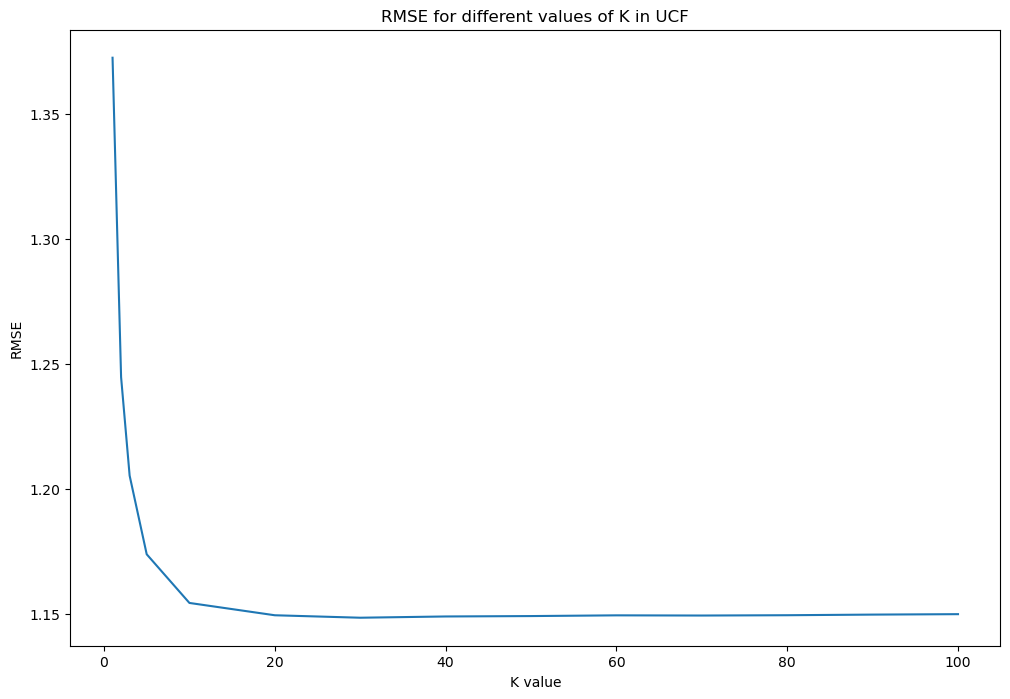

In [34]:
min_rmse_fast_ucf, _ = plot_fast_tuned_algorithms(results_fast_RMSE)

The minimum $RMSE$ is achieved for $k=30$ and is equal to $RMSE_{UCF_{30}}=1.1486588479056647$, as we have expected.

In [35]:
fast_ucf_30_RMSE = min_rmse

## Normalized User-Based Collaborative Filterring TODO CHANGE IT

In this implementation, we add to the score function the users mean rating and we simultaniously subtract the mean rating of the similar users from each movie they have rated. The computed rating for a $(u,m)$ pair is:

$$
p(u,m)= \mu_{R[u,:]} + \frac{\sum_{u'\in N_k(u,m)}sim(u,u')(R[u',m]-\mu_{R[u',:]})}{\sum_{u' \in N_k(u,m)}sim(u,u')}
$$

In [36]:
def compute_score_normalized(k_ratings: np.array, k_similarities: np.array, best_users: np.array):
    mean_ratings = [user_mean(R=R, u=user) for user in best_users]
    
    denominator = np.sum(k_similarities)
    if denominator == 0:
        return 0
    
    return (k_ratings- np.array(mean_ratings)).dot(k_similarities) / np.sum(k_similarities)

In [37]:
def normalized_ucf_predict(u: int, m: int, k: int):
    users_predicted_movie = item_users(R=R, m=m)
    mean_ratings = np.array([user_mean(R=R, u=user) for user in users_predicted_movie])

    if len(users_predicted_movie) == 0:
        return user_mean(R=R, u=u)
    
    best_k_users, sims = similar_users(R=R, u=u, m_users=users_predicted_movie, k=k)
    
    return user_mean(R=R, u=u) + compute_score_normalized(k_ratings=R[best_k_users, m].toarray().flatten(), k_similarities=sims, best_users=best_k_users)

In [38]:
def normalized_ucf_predict_list(u: int, m: int, k: np.array):
    scores = []
    start_idx = len(k)-1
    k_max = k[start_idx]
    k_min = k[0]
    
    users_predicted_movie = item_users(R=R, m=m)
    mean_ratings = np.array([user_mean(R=R, u=user) for user in users_predicted_movie])

    # case if no users have rated movie m => assign average rating of user u
    if len(users_predicted_movie) == 0:
        return np.array([user_mean(R=R, u=u)]*len(k))

    best_k_users, sims = similar_users(R=R, u=u, m_users=users_predicted_movie, k=k_max)
    user_mean_rating = user_mean(R=R, u=u)

    scores.append(user_mean_rating + compute_score_normalized(k_ratings=R[best_k_users, m].toarray().flatten(), k_similarities=sims, best_users=best_k_users))
    
    while k_max != k_min:
        start_idx = start_idx - 1
        k_max = k[start_idx]

        sims = sims[:k_max]
        best_k_users = best_k_users[:k_max]
    
        scores.append(user_mean_rating + compute_score_normalized(k_ratings=R[best_k_users, m].toarray().flatten(), k_similarities=sims, best_users=best_k_users))


    return np.array(scores)

In [39]:
%%time
K = np.array([1,2,3,5,10,20,30,40,50,60,70,80,90,100])
users = test[:,0].astype(int)
movies = test[:,1].astype(int)

results_normalized_ucf_RMSE = np.array([normalized_ucf_predict_list(u,m,K) for u,m in zip(users, movies)])

CPU times: user 8min 24s, sys: 150 ms, total: 8min 24s
Wall time: 8min 24s


RMSE for k=100: 1.1525429662837012
RMSE for k=90: 1.1523703148411624
RMSE for k=80: 1.152125350687937
RMSE for k=70: 1.15200616889462
RMSE for k=60: 1.1520802795703204
RMSE for k=50: 1.1518027234971933
RMSE for k=40: 1.151643425757283
RMSE for k=30: 1.1511280089034344
RMSE for k=20: 1.1520812910754317
RMSE for k=10: 1.1568642434239509
RMSE for k=5: 1.1761814685081324
RMSE for k=3: 1.2073340791089309
RMSE for k=2: 1.2465478732676718
RMSE for k=1: 1.3730363053179584
Minimum RMSE achieved for K=30: 1.1511280089034344


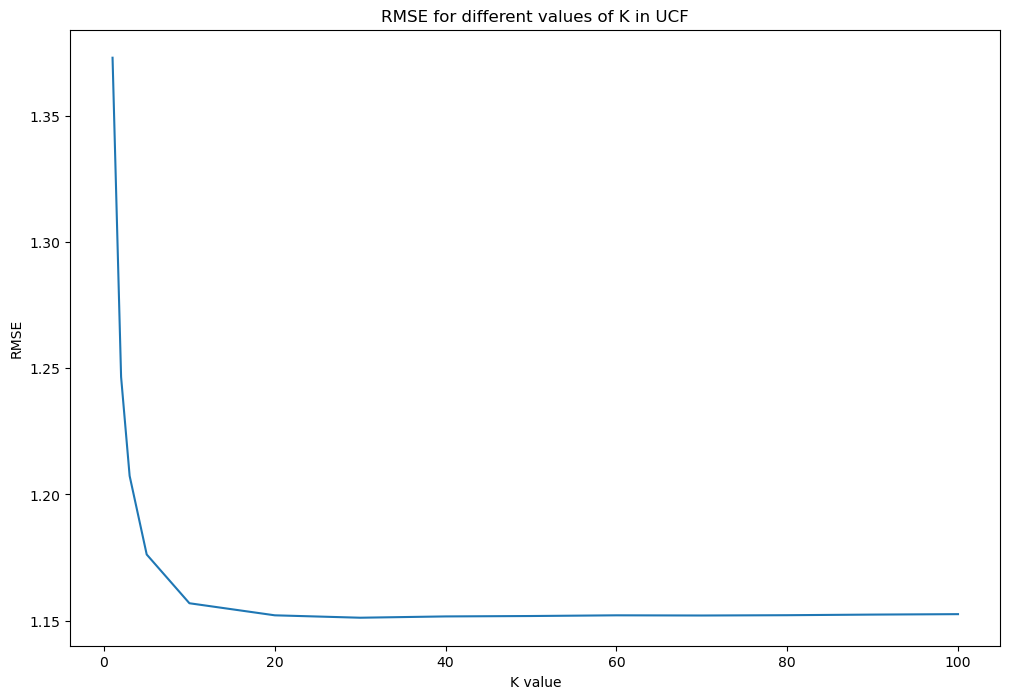

In [41]:
min_rmse, _ = plot_fast_tuned_algorithms(results_normalized_ucf_RMSE)

In [42]:
normalized_ucf_RMSE = min_rmse

## Item-Based Collaborative Filterring Note: bug occured, did not run it for the whole test dataset

$$
p(u,m)= \frac{\sum_{m'\in N_k(u,m')}sim(m,m')R[u,m']}{\sum_{m' \in N_k(u,m)}sim(m,m')}
$$

In [47]:
def movie_mean(R: csr_matrix, m: int):
    return R[R[:,m].nonzero()].mean()

def user_items(R: csr_matrix, u: int):
    return R[u,:].nonzero()[1]

In [48]:
def similar_movies(R: csr_matrix, m: int, m_movies: np.array, k: int):
    sims = cosine_similarity(R[:,m].T, R[:, m_movies].T).flatten()

    topk_idx = np.argsort(sims)[::-1]
    return m_movies[topk_idx[:k]], sims[topk_idx[:k]]

In [49]:
def icf_predict(u: int, m: int, k: int):
    movies_predicted_u = user_items(R=R, u=u) # movies that have been rated by user u

    if len(movies_predicted_u) == 0:
        return movie_mean(R=R, m=0)
    
    best_k_movies, sims = similar_movies(R=R, m=m, m_movies = movies_predicted_u, k=k)

    return compute_score(k_ratings=R[u,best_k_movies], k_similarities=sims)    

In [ ]:
def icf_predict_list(u: int, m: int, k: np.array):
    scores = []
    start_idx = len(k)-1
    k_max = k[start_idx]
    k_min = k[0]
    
    movies_predicted_u = user_items(R=R, u=u)

    if len(movies_predicted_u) == 0:
        return np.array([movie_mean(R=R, m=m)]*len(k))


    best_k_movies, sims = similar_movies(R=R, m=m, m_movies=movies_predicted_u, k=k_max)
    scores.append(compute_score(k_ratings=R[u, best_k_movies], k_similarities=sims))
    
    while k_max != k_min:
        start_idx = start_idx - 1
        k_max = k[start_idx]

        sims = sims[:k_max]
        best_k_movies = best_k_movies[:k_max]
    
        scores.append(compute_score(k_ratings=R[u, best_k_movies], k_similarities=sims))


    return np.array(scores)

## Results

In [50]:
results_dict = {
    "algorithms": [
        "User Average",
        "Item Average",
        "SVD",
        "UCF",
        "Normalized UCF"
    ],
    "RMSE": [
        ua_RMSE,
        ia_RMSE,
        svd_RMSE,
        slow_ucf_30_RMSE,
        normalized_ucf_RMSE, 
    ]
}

df = pd.DataFrame(results_dict)
df.sort_values(by='RMSE')

,algorithms,RMSE
0,User Average,0.961285
1,Item Average,0.986019
3,UCF,1.148659
4,Normalized UCF,1.151128
2,SVD,2.921219


As we see, we get the best RMSE's for the **User Average** and **Item Average**.

The **SVD** performs worse than all the algorithms, possibly because we have a diverse dataset and the latent factors do not represent the concepts accurately.

All our **UCF** implementations perform similarly, namely the fast and slow implementations produce the same results, as expected, while the **Normalized UCF** performs slightly worse and takes 8 minutes to make all the 10.000 predictions. 